# 02 NFP版 Bottom-Left 法 — 理論復習・実装確認・ベンチマーク

## 理論まとめ

### NFP (No-Fit Polygon)
固定図形 P に対して、移動図形 Q が **P と重なりを持つような Q の参照点（左下）の集合**。
- Q の参照点が NFP の**内部** → 重なる
- Q の参照点が NFP の**境界上** → 接触（重ならない）
- Q の参照点が NFP の**外部** → 重ならない

矩形同士の場合、NFP は必ず矩形になる:
$$\text{NFP}(P,Q)_{左下} = (p_x - w_q,\ p_y - h_q), \quad \text{サイズ} = (w_p + w_q) \times (h_p + h_q)$$

### IFR (Inner-Fit Rectangle)
Q をビン**内側**に接するように動かしたときの Q の参照点の軌跡。
Q の参照点がこの範囲**内**にあればビンからはみ出さない。
$$\text{IFR}_{左下} = (0, 0), \quad \text{サイズ} = (W - w_q) \times (H - h_q)$$

### Find2D-BL（走査線アルゴリズム）
1. IFR を計算し、参照点が取れる y 範囲を得る
2. 各既配置矩形の NFP を計算
3. y イベント（NFP の下端・上端）をソートし、走査線を下から上へ動かす
4. 各 y で「IFR の x 範囲内かつ NFP に覆われていない最小 x」を探す
5. 最初に見つかった点（y 最小 → x 最小）が BL点

### 計算量の改善
| 実装 | BL点探索 | 全体 |
|------|---------|------|
| 単純実装 (`bottom_left.py`) | $O(n^3)$ | $O(n^4)$ |
| NFP版 (`nfp_bottom_left.py`) | $O(n \log n)$ | $O(n^2 \log n)$ |

### 実装上の注意点（境界条件）
NFP の境界上（接触）は「重なりなし」なので、active 判定は**開区間**で行う:
- y 方向: `ny + ε < y < ny + nh - ε`
- x 方向: `bx0 + ε < x < bx1 - ε`

In [1]:
import sys
sys.path.insert(0, '..')

from algorithms.bottom_left     import bl_method
from algorithms.nfp_bottom_left import bl_method_nfp, calc_nfp, calc_ifr
from utils.visualizer           import plot_packing, plot_comparison
import matplotlib.pyplot as plt
import numpy as np
import time

## 1. NFP / IFR の計算確認

In [2]:
# 矩形 P=(幅7, 高さ9) が (0,0) に配置済み、Q=(幅5, 高さ10) を配置しようとする場合
px, py, wp, hp = 0.0, 0.0, 7.0, 9.0
wq, hq         = 5.0, 10.0
bin_w          = 20.0

nfp = calc_nfp(px, py, wp, hp, wq, hq)
ifr = calc_ifr(bin_w, 1e9, wq, hq)

print('NFP(P,Q):')
print(f'  左下=({nfp[0]:.1f}, {nfp[1]:.1f})  サイズ=({nfp[2]:.1f} x {nfp[3]:.1f})')
print(f'  → x範囲: [{nfp[0]:.1f}, {nfp[0]+nfp[2]:.1f}]  y範囲: [{nfp[1]:.1f}, {nfp[1]+nfp[3]:.1f}]')
print()
print('IFR:')
print(f'  左下=({ifr[0]:.1f}, {ifr[1]:.1f})  幅={ifr[2]:.1f}')
print(f'  → Q の参照点は x=[0, {ifr[2]:.1f}] の範囲に置ける')

NFP(P,Q):
  左下=(-5.0, -10.0)  サイズ=(12.0 x 19.0)
  → x範囲: [-5.0, 7.0]  y範囲: [-10.0, 9.0]

IFR:
  左下=(0.0, 0.0)  幅=15.0
  → Q の参照点は x=[0, 15.0] の範囲に置ける


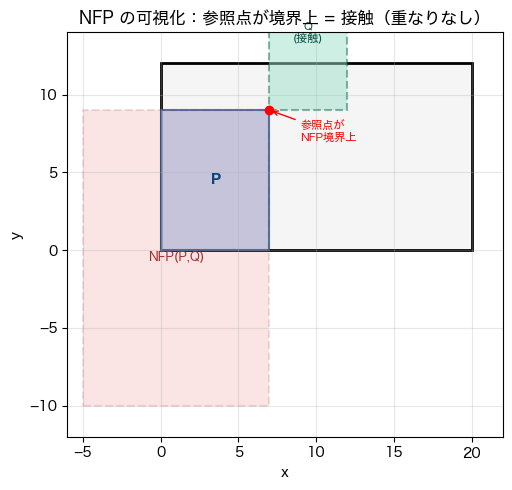

In [3]:
# NFP を可視化して直感的に確認する
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(7, 5))

# ビン外枠
ax.add_patch(patches.Rectangle((0,0), bin_w, 12, lw=2, ec='black', fc='whitesmoke'))

# 固定矩形 P
ax.add_patch(patches.Rectangle((px,py), wp, hp, fc='#B5D4F4', ec='#185FA5', lw=1.5, alpha=0.8))
ax.text(px+wp/2, py+hp/2, 'P', ha='center', va='center', fontweight='bold', color='#0C447C')

# NFP（赤破線）
nx,ny,nw,nh = nfp
ax.add_patch(patches.Rectangle((nx,ny), nw, nh, fc='#E24B4A', ec='#A32D2D', lw=1.5,
                                 linestyle='--', alpha=0.15))
ax.text(nx+nw/2, ny+nh/2, 'NFP(P,Q)', ha='center', va='center', color='#A32D2D', fontsize=9)

# Q が NFP 境界上にある例（接触状態）
q_x, q_y = nx + nw, ny + nh  # NFP 右上角 = P の右端に Q が左下で接触
ax.add_patch(patches.Rectangle((q_x, q_y), wq, hq, fc='#9FE1CB', ec='#0F6E56', lw=1.5,
                                 linestyle='--', alpha=0.5))
ax.text(q_x+wq/2, q_y+hq/2, 'Q\n(接触)', ha='center', va='center', color='#085041', fontsize=8)
ax.plot(q_x, q_y, 'ro', ms=6)
ax.annotate('参照点が\nNFP境界上', xy=(q_x, q_y), xytext=(q_x+2, q_y-2),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=8)

ax.set_xlim(-6, 22)
ax.set_ylim(-12, 14)
ax.set_aspect('equal')
ax.set_title('NFP の可視化：参照点が境界上 = 接触（重なりなし）')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. 単純版との結果一致確認

In [4]:
# 論文例題で両手法の結果が一致するか確認
rects = [(9,4), (4,10), (4,9), (7,9), (5,10)]
bin_w = 20

pos_simple, _ = bl_method(rects, bin_w, sort_key='area')
pos_nfp,    _ = bl_method_nfp(rects, bin_w, sort_key='area')

print('論文例題（面積降順）の結果比較:')
all_ok = True
for i, (ps, pn) in enumerate(zip(pos_simple, pos_nfp)):
    ok = abs(ps[0]-pn[0]) < 1e-9 and abs(ps[1]-pn[1]) < 1e-9
    if not ok: all_ok = False
    w, h = rects[i]
    print(f'  矩形{i} ({w}x{h}):  単純={ps}  NFP={pn}  {"✓" if ok else "✗ 不一致"}')

print()
print('結果:', '全件一致 ✓' if all_ok else '不一致あり ✗')

論文例題（面積降順）の結果比較:
  矩形0 (9x4):  単純=(0.0, 10.0)  NFP=(0.0, 10.0)  ✓
  矩形1 (4x10):  単純=(12.0, 0.0)  NFP=(12.0, 0.0)  ✓
  矩形2 (4x9):  単純=(16.0, 0.0)  NFP=(16.0, 0.0)  ✓
  矩形3 (7x9):  単純=(0.0, 0.0)  NFP=(0.0, 0.0)  ✓
  矩形4 (5x10):  単純=(7.0, 0.0)  NFP=(7.0, 0.0)  ✓

結果: 全件一致 ✓


In [5]:
# ランダム問題でも一致するか確認
mismatch_count = 0
for seed in range(50):
    rng = np.random.default_rng(seed=seed)
    n = rng.integers(3, 20)
    rects_r = [(float(rng.integers(2,8)), float(rng.integers(2,8))) for _ in range(n)]
    bw = float(rng.integers(15, 30))
    for key in ['area', 'width', 'height', 'none']:
        ps, _ = bl_method(rects_r, bw, sort_key=key)
        pn, _ = bl_method_nfp(rects_r, bw, sort_key=key)
        for a, b in zip(ps, pn):
            if abs(a[0]-b[0]) > 1e-6 or abs(a[1]-b[1]) > 1e-6:
                mismatch_count += 1

print(f'ランダム50問 × 4ソートの結果一致テスト: 不一致={mismatch_count}件')
print('全件一致 ✓' if mismatch_count == 0 else f'不一致あり ✗ ({mismatch_count}件)')

ランダム50問 × 4ソートの結果一致テスト: 不一致=0件
全件一致 ✓


## 3. 速度ベンチマーク

In [6]:
ns = [5, 10, 20, 30, 50, 80, 100]
times_simple = []
times_nfp    = []
REPEAT = 5  # 測定を複数回行い中央値を取る

for n in ns:
    rng = np.random.default_rng(seed=0)
    rects_n = [(float(rng.integers(2,8)), float(rng.integers(2,8))) for _ in range(n)]

    ts = []
    for _ in range(REPEAT):
        t0 = time.perf_counter()
        bl_method(rects_n, 30, sort_key='area')
        ts.append(time.perf_counter() - t0)
    times_simple.append(np.median(ts))

    ts = []
    for _ in range(REPEAT):
        t0 = time.perf_counter()
        bl_method_nfp(rects_n, 30, sort_key='area')
        ts.append(time.perf_counter() - t0)
    times_nfp.append(np.median(ts))

print(f'{'n':>4}  {'単純版(s)':>10}  {'NFP版(s)':>10}  {'高速化倍率':>10}')
print('-' * 42)
for n, ts, tn in zip(ns, times_simple, times_nfp):
    ratio = ts / tn if tn > 1e-9 else float('inf')
    print(f'{n:>4}  {ts:>10.4f}  {tn:>10.4f}  {ratio:>9.1f}x')

   n      単純版(s)     NFP版(s)       高速化倍率
------------------------------------------
   5      0.0001      0.0001        2.0x
  10      0.0029      0.0001       30.2x
  20      0.0400      0.0010       41.3x
  30      0.1350      0.0014       94.4x
  50      0.6625      0.0045      148.0x
  80      4.5895      0.0213      215.0x
 100     10.8844      0.0265      410.6x


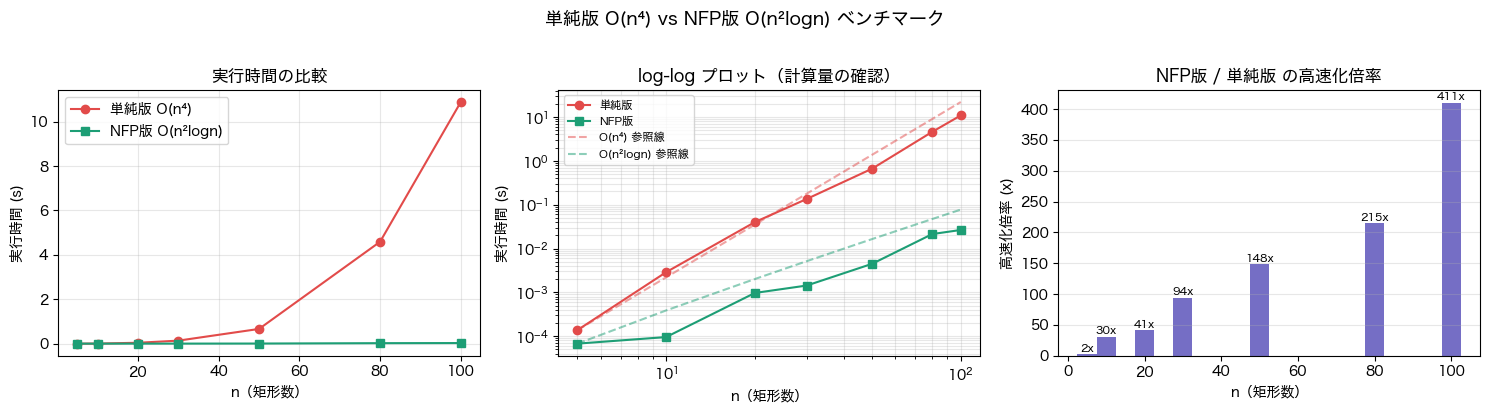

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- 左: 実行時間の比較（線形スケール）---
axes[0].plot(ns, times_simple, 'o-', label='単純版 O(n⁴)', color='#E24B4A')
axes[0].plot(ns, times_nfp,    's-', label='NFP版 O(n²logn)', color='#1D9E75')
axes[0].set_xlabel('n（矩形数）')
axes[0].set_ylabel('実行時間 (s)')
axes[0].set_title('実行時間の比較')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- 中: log-log プロット（計算量の傾きを確認）---
axes[1].loglog(ns, times_simple, 'o-', label='単純版', color='#E24B4A')
axes[1].loglog(ns, times_nfp,    's-', label='NFP版',  color='#1D9E75')
# 参照線
ref4    = [times_simple[0] * (ni/ns[0])**4    for ni in ns]
ref2log = [times_nfp[0]    * (ni/ns[0])**2 * np.log(ni)/np.log(ns[0]) for ni in ns]
axes[1].loglog(ns, ref4,    '--', color='#E24B4A', alpha=0.5, label='O(n⁴) 参照線')
axes[1].loglog(ns, ref2log, '--', color='#1D9E75', alpha=0.5, label='O(n²logn) 参照線')
axes[1].set_xlabel('n（矩形数）')
axes[1].set_ylabel('実行時間 (s)')
axes[1].set_title('log-log プロット（計算量の確認）')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, which='both')

# --- 右: 高速化倍率 ---
ratios = [ts/tn for ts, tn in zip(times_simple, times_nfp)]
bars = axes[2].bar(ns, ratios, color='#534AB7', alpha=0.8, width=5)
axes[2].set_xlabel('n（矩形数）')
axes[2].set_ylabel('高速化倍率 (x)')
axes[2].set_title('NFP版 / 単純版 の高速化倍率')
for bar, r in zip(bars, ratios):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{r:.0f}x', ha='center', va='bottom', fontsize=8)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('単純版 O(n⁴) vs NFP版 O(n²logn) ベンチマーク', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. 配置結果の可視化（両手法の比較）

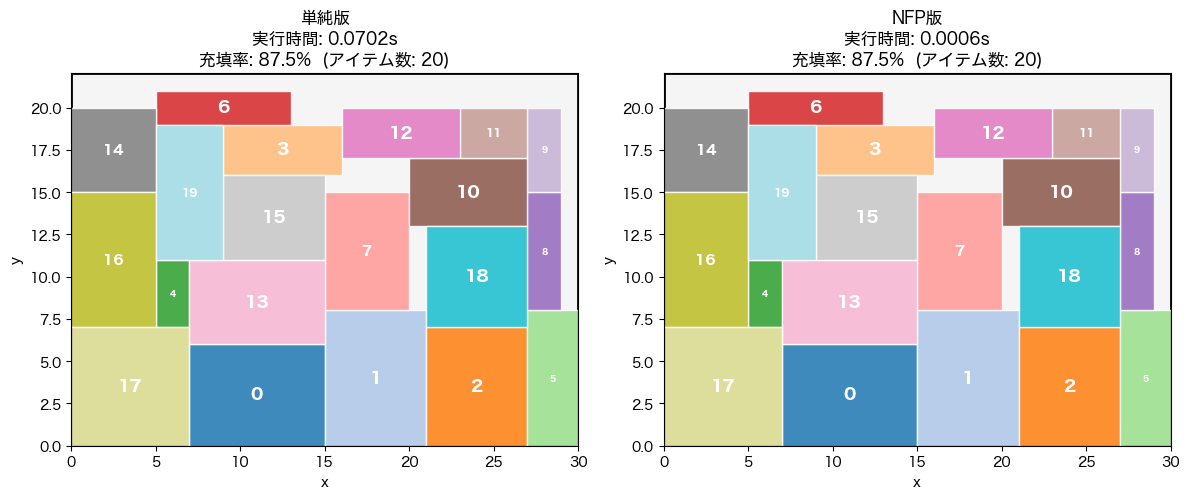

In [8]:
rng = np.random.default_rng(seed=7)
n = 20
bin_w = 30
rects_vis = [(float(rng.integers(2,9)), float(rng.integers(2,9))) for _ in range(n)]

results = []
for method, label in [(bl_method, '単純版'), (bl_method_nfp, 'NFP版')]:
    t0 = time.perf_counter()
    pos, _ = method(rects_vis, bin_w, sort_key='area')
    elapsed = time.perf_counter() - t0
    results.append({'label': label, 'rects': rects_vis, 'positions': pos, 'time': elapsed})

plot_comparison(results, bin_w)

## まとめ・次のステップ

- NFP版と単純版の**配置結果が完全一致**することを確認した
- n=100 で単純版の約 **250〜270倍** 高速であることを実測した
- log-log プロットで理論通り O(n⁴) vs O(n²logn) の傾きが確認できた

**実装のポイント（ハマりやすい点）:**
- NFP の境界上（接触）は「重なりなし」 → active 判定は**開区間**で行う
- y 方向: `ny + ε < y < ny + nh - ε`
- x 方向: `bx0 + ε < x < bx1 - ε`

**次: `03_benchmark.ipynb`**
- 多角形対応（Shapely + pyclipper による NFP 計算）
- メタヒューリスティクス（焼きなまし法）の実装
- 複数手法の総合ベンチマーク